On reprend les Labs / TP du cours en l'appliquant à notre jeu de données.

In [11]:
import regex as re
import manuscripts
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
def get_clean_mss_id(mss_str):
    if not mss_str: return "Inconnu"
    # On coupe avant 'ff.' ou 'f.' ou 'f ' pour ne garder que la cote
    # Exemple: "Arundel 409. ff. 54-77" -> "Arundel 409"
    clean = re.split(r'\s+\.?f{1,2}\.', mss_str)[0]
    return clean.strip('. ')

def gen_catalog():
    # préférer la fonciton gen_catalog_mss_id()
    all_records = []
    for category, manuscripts_list in manuscripts.CORRESPONDENCE_OPERA_CORRECTED_MSS.items():
        for record in manuscripts_list:
            record_with_category = record.copy()
            record_with_category['category'] = category
            all_records.append(record_with_category)
    return pd.DataFrame(all_records)

def gen_catalog_mss_id():
    # Transformation du dictionnaire en DataFrame
    all_data = []
    for category, items in manuscripts.CORRESPONDENCE_OPERA_CORRECTED_MSS.items():
        for item in items:
            new_item = item.copy()
            new_item['category'] = category
            new_item['mss_id'] = get_clean_mss_id(item['mss'])
            all_data.append(new_item)

    return pd.DataFrame(all_data)

624
Graph with 624 nodes and 502 edges
Two different visualisations


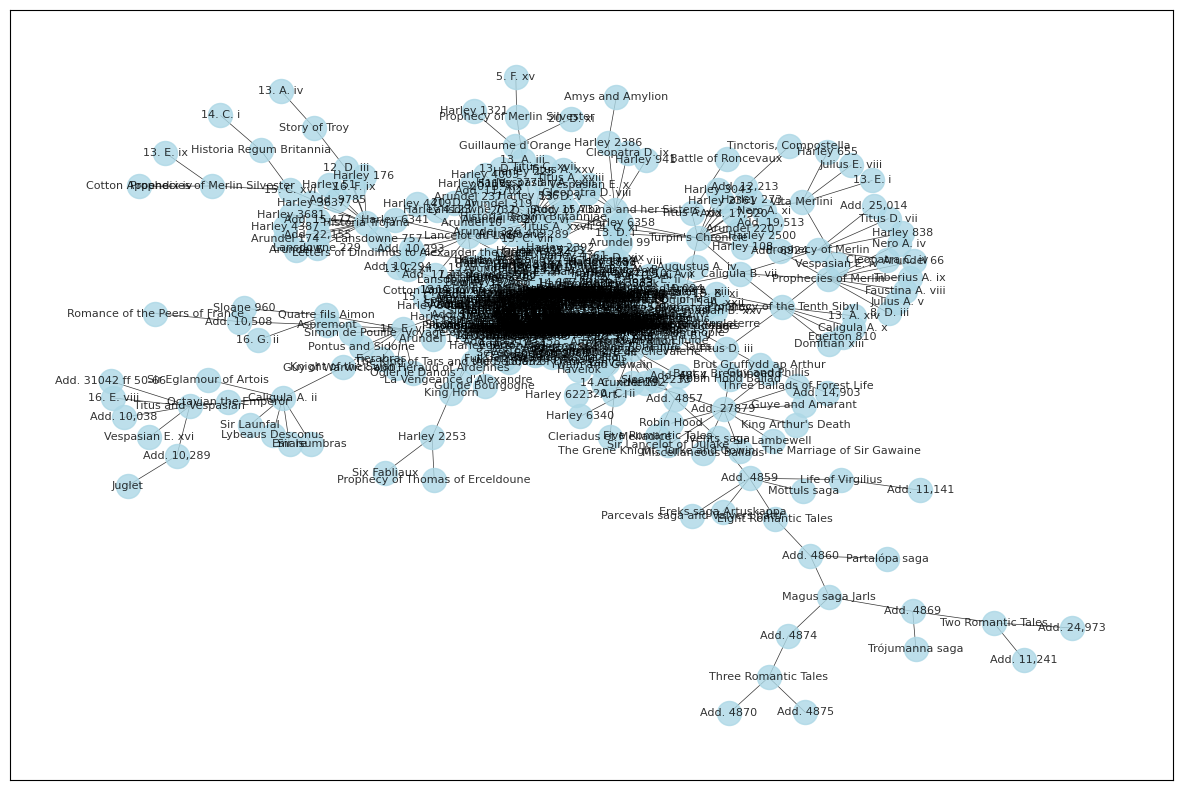

In [13]:
df_mss = gen_catalog_mss_id() 
manuscrits = df_mss['mss_id'].unique().tolist()
oeuvres = df_mss['name'].unique().tolist()

# Création graphe biparti
# wikipédia: 
#       When modelling relations between two different classes of objects, bipartite graphs very often arise naturally. 
#       For instance, a graph of football players and clubs, with an edge between a player and a club if the player has 
#       played for that club, is a natural example of an affiliation network, a type of bipartite graph used in social 
#       network analysis.

G = nx.Graph()
G.add_nodes_from(manuscrits, bipartite=0)
G.add_nodes_from(oeuvres, bipartite=1)

for _, row in df_mss.iterrows():
    G.add_edge(row['mss_id'], row['name'])

print(len(manuscrits) + len(oeuvres))
print(G)

print("Two different visualisations")

plt.figure(figsize=(15, 10))
plt.tight_layout()

nx.draw_networkx(G, 
    pos=nx.kamada_kawai_layout(G), #nx.spring_layout(G, k=3, iterations=50),
    node_size=300,
    node_color='lightblue',
    font_size=8,
    width=0.5,
    alpha=0.8
)
plt.show()

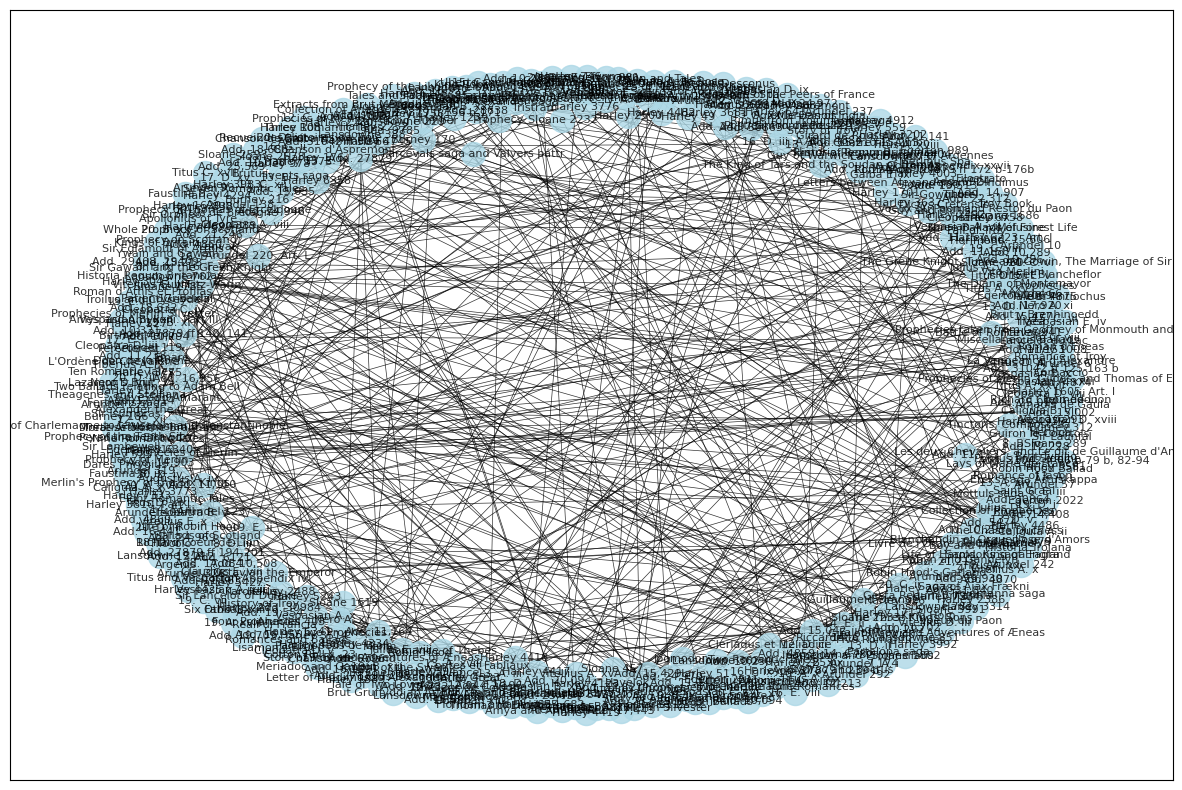

In [14]:
plt.figure(figsize=(15, 10))
plt.tight_layout()

nx.draw_networkx(G, 
    pos=nx.spring_layout(G, k=3, iterations=50),
    node_size=300,
    node_color='lightblue',
    font_size=8,
    width=0.5,
    alpha=0.8
)
plt.show()

In [15]:
G.nodes()

NodeView(('4. C. xi', '5. F. xv', '6. C. viii', '6. E. iii', '7. A. i', '8. B. iv', '8. D. iii', '8. F. ix', '9. B. ix', '10. A. x', '12. C. iv', '12. C. xii', '12. C. xx', '12. D. iii', '13. A. i', '13. A. iii', '13. A. iv', '13. A. v', '13. A. xiv', '13. A. xviii', '13. A. xxi', '13. C. xii', '13. D. i', '13. D. ii', '13. D. v', '13. E. i', '13. E. ix', '14. C. i', '14. C. xi', '14. E. ii', '14. E. iii', '15. A. x', '15. A. xxii', '15. B. xi', '15. C. vi', '15. C. xvi', '15. E. v', '15. E. vi', '16. C. iv. A. B', '16. C. xxiii', '16. D. iii. A. B', '16. E. viii', '16. E', '16. F. v', '16. F. ix', '16. G. ii', '17. B. xliii', '17. D. xv', '17. E. ii', '18. B. ii', '18. C. ii', '18. D. ii', '18. D. vi', '19. A. xviii', '19. B. vii', '19. B. xii', '19. B. xiii', '19. C. vii', '19. C. viii', '19. D. i', '19. E. ii', '19. E. iii', '20. A. v', '20. A. xvii', '20. B. xix', '20. B. xx', '20. C. ii', '20. C. vi', '20. D. ii', '20. D. iii', '20. D. iv', '20. D. vii', '20. D. xi', 'Julius A. v'

In [16]:
G.edges()

EdgeView([('4. C. xi', 'Historia Regum Britanniae'), ('4. C. xi', "Turpin's Chronicle"), ('5. F. xv', 'Prophecy of Merlin Silvester'), ('6. C. viii', 'Dares Phrygius'), ('6. E. iii', 'Letters between Alexander and Dindimus'), ('7. A. i', 'Letters between Alexander and Dindimus'), ('8. B. iv', 'Alexandreis'), ('8. D. iii', 'Prophecies of Merlin'), ('8. F. ix', 'Guy of Warwick'), ('9. B. ix', 'Prophecy on Scotland'), ('10. A. x', 'Dares Phrygius'), ('12. C. iv', 'Alexander the Great'), ('12. C. xii', 'Prophecy'), ('12. C. xii', 'Fulk Fitz-Warin'), ('12. C. xii', 'Amya and Amylion'), ('12. C. xx', 'Tale of Two Lovers'), ('12. D. iii', 'Historia Trojana'), ('12. D. iii', 'Story of Troy'), ('13. A. i', 'Alexander the Great'), ('13. A. iii', 'Historia Regum Britanniae'), ('13. A. iii', 'Prophecy of Merlin Silvester'), ('13. A. iv', 'Story of Troy'), ('13. A. v', 'Alexander the Great'), ('13. A. v', 'Dares Phrygius'), ('13. A. v', 'Historia Regum Britanniae'), ('13. A. xiv', 'Prophecy of the 

In [17]:
print(list(G.neighbors('Historia Regum Britanniae')))
print(G.degree('Historia Regum Britanniae'))

['4. C. xi', '13. A. iii', '13. A. v', '13. D. i', '13. D. ii', '13. D. v', 'Nero D. viii', 'Galba E. xi', 'Vespasian A. xxiii', 'Vespasian E. x', 'Titus A. xviii', 'Titus A. xxv', 'Titus A. xxvii', 'Titus C. xvii', 'Cleopatra D. viii', 'Harley 225', 'Harley 536', 'Harley 3773', 'Harley 4003', 'Harley 4123', 'Harley 5115', 'Harley 6358', 'Lansdowne 732', 'Arundel 10', 'Arundel 237', 'Arundel 319', 'Arundel 326', 'Arundel 403', 'Arundel 409', 'Sloane 289', 'Add. 11,702', 'Add. 15,732']
32


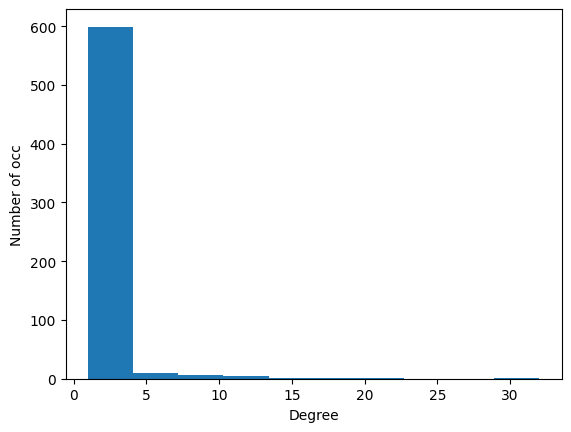

In [18]:
plt.hist(list(dict(nx.degree(G)).values()))
plt.xlabel('Degree')
plt.ylabel('Number of occ')
plt.show()

In [19]:
print(list(nx.all_simple_paths(G, 'Historia Regum Britanniae', 'Lancelot du Lac')))
print(list(nx.all_simple_paths(G, 'Historia Regum Britanniae', 'Prophecies of Merlin')))
print(nx.shortest_path(G,  'Historia Regum Britanniae', 'Prophecies of Merlin'))

[]
[['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Caligula B. vii', 'Prophecy of Merlin', 'Cleopatra C. iv', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Caligula B. vii', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Vespasian A. xiii', 'Apollonius of Tyre', 'Titus D. iii', 'Prophecy of the Tenth Sibyl', '15. A. xxii', 'Dares Phrygius', 'Caligula B. vii', 'Prophecy of Merlin', 'Cleopatra C. iv', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Vespasian A. xiii', 'Apollonius of Tyre', 'Titus D. iii', 'Prophecy of the Tenth Sibyl', '15. A. xxii', 'Dares Phrygius', 'Caligula B. vii', 'Prophecies of Merlin'], ['Historia Regum Britanniae', '4. C. xi', "Turpin's Chronicle", 'Vespasian A. xiii', 'Apollonius of Tyre', 'Titus D. iii', 'Prophecy of the Tenth Sibyl', '15. B. xi', 'Dares Phrygius', 'Caligula B. vii', 'Prophecy of Merlin', 'Cleopatra

In [20]:
# Caractéristiques du graphe:
# On regarde parmi toutes les possibilités.

print("Connexe:", nx.is_connected(G))
if not nx.is_connected(G):
    print("Nombre de composantes connexes:", nx.number_connected_components(G))
else:
    print("Diameter", nx.diameter(G))
print("Densité:", nx.density(G))

print("*"*50)
print("Connectivité algébrique:", nx.algebraic_connectivity(G))
print("Spectral_ordering:", nx.spectral_ordering(G))

print("Spectres")
print("\t*Matrice adjacence", [float(elem.real) for elem in nx.adjacency_spectrum(G)])
print("\t*Matrice laplacienne", nx.laplacian_spectrum(G))

Connexe: False
Nombre de composantes connexes: 142
Densité: 0.002582623369140223
**************************************************
Connectivité algébrique: 0.0
Spectral_ordering: ['Juglet', 'Add. 10,289', 'Vespasian E. xvi', '16. E. viii', 'Add. 10,038', 'Add. 31042 ff 50-66', 'Titus and Vespasian', 'Emare', 'Sir Launfal', 'Sir Eglamour of Artois', 'Lybeaus Desconus', 'Sir Isumbras', 'Octavian the Emperor', 'Caligula A. ii', 'Knight of the Swan', 'Romance of the Peers of France', 'Add. 10,508', 'Sloane 960', '16. G. ii', 'Aspremont', 'Quatre fils Aimon', 'Ogier le Danois', 'Pontus and Sidoine', 'Guy of Warwick and Heraud of Ardennes', 'Fierabras', 'Simon de Pouille', '15. E. vi', 'Cotton Appendix iv', '13. E. ix', 'Prophecies of Merlin Silvester', '14. C. i', 'Historia Regum Britannia', '15. C. xvi', '13. A. iv', 'Story of Troy', '12. D. iii', 'Add. 22,155', 'Lansdowne 229', 'Arundel 174', 'Harley 4387', 'Harley 3681', 'Harley 3637', '16. F. ix', 'Harley 51', 'Arundel 6', 'Add. 9785',

In [21]:
# Liste de la taille de chaque composante
comp_sizes = [len(c) for c in nx.connected_components(G)]
print(f"Taille de la plus grosse composante : {max(comp_sizes)}")
print(sorted(comp_sizes))
print(sum(comp_sizes))

Taille de la plus grosse composante : 199
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 6, 7, 7, 8, 9, 9, 9, 12, 13, 34, 199]
624


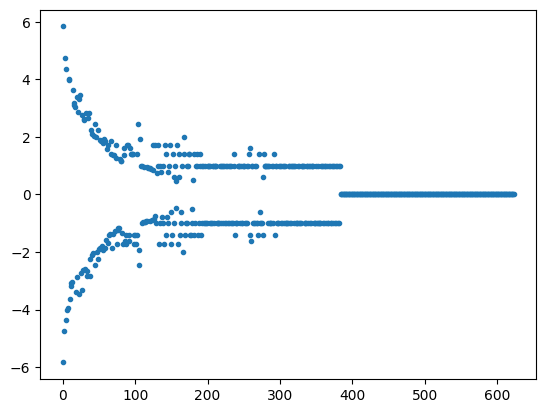

In [22]:
plt.scatter([x for x in range(len(nx.adjacency_spectrum(G)))], [float(elem.real) for elem in nx.adjacency_spectrum(G)], marker='.')

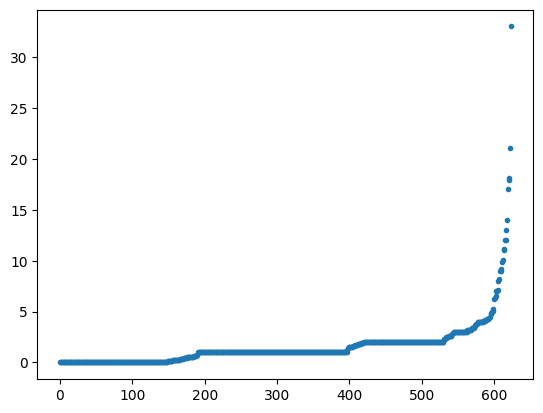

In [23]:
plt.scatter([x for x in range(len(nx.laplacian_spectrum(G)))], nx.laplacian_spectrum(G), marker='.')

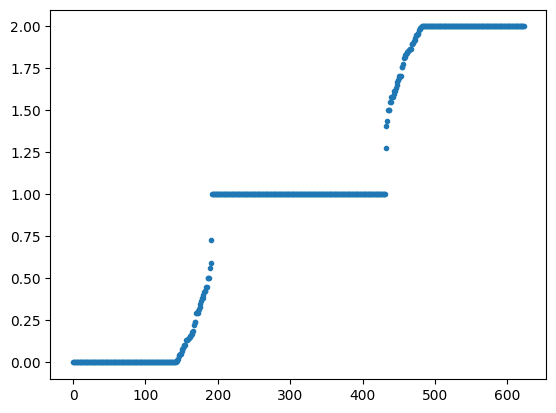

In [24]:
plt.scatter([x for x in range(len(nx.normalized_laplacian_spectrum(G)))], nx.normalized_laplacian_spectrum(G), marker='.')

On regarde quelques fonctions d'intérêt que l'on peut trouver dans https://networkx.org/documentation/stable/reference/algorithms

In [25]:
print("Average clustering coefficient:", nx.average_clustering(G))
print("Min weighted dominating set:", nx.approximation.min_weighted_dominating_set(G))

Average clustering coefficient: 0.0
Min weighted dominating set: {'Prophecy of Merlin', 'Titus A. xx', 'Lansdowne 362', '13. A. xviii', 'Harley 559', 'Harley 1717', 'Add. 27,979', 'Historia Trojana', 'Perceforest', 'Add. 18,922', 'Caligula A. ix', 'Add. 15,566', 'Julius D. xi', 'Lansdowne 782', 'Prophecies', '9. B. ix', 'Letter of Dindimus to Alexander the Great', '16. C. xxiii', 'Vespasian D. xviii', 'Guy of Warwick', 'Add. 11,238', 'Add. 29408, 29409', 'Add. 4863', 'Harley 3810. Part I', 'Add. 27879 ff 172 b-176b', "Guillaume d'Orange", 'Add. 16,888', 'Galba E. ix', 'Add. 11,174', 'Harley 3581', 'Thomas of Erceldoune', 'Egerton 2515', 'Add. 4884', 'Harley 978', 'Filocolo', 'Add. 27879 f 239 b', 'Arundel 57', 'Vita Merlini', 'Add. 27879 f 248', 'Arundel 220. Art. L', 'Prophecy of the Tenth Sibyl', 'Add. 4869', 'Add. 18,688', 'Alexander the Great', 'Otho C. xiii', 'Add. 28638', '17. B. xliii', 'Add. 16,955', 'Add. 10,321', 'Add. 10,295', 'Lansdowne 380', 'Add. 11,164', 'Historia Regum 

In [26]:
print("Degree assortativity coefficient:", nx.degree_assortativity_coefficient(G))
print("Average neighbor degree:", nx.average_neighbor_degree(G))
print("Average degree connectivity:", nx.average_degree_connectivity(G))


Degree assortativity coefficient: -0.22441265223088377
Average neighbor degree: {'4. C. xi': 24.5, '5. F. xv': 2.0, '6. C. viii': 17.0, '6. E. iii': 2.0, '7. A. i': 2.0, '8. B. iv': 8.0, '8. D. iii': 9.0, '8. F. ix': 8.0, '9. B. ix': 1.0, '10. A. x': 17.0, '12. C. iv': 20.0, '12. C. xii': 1.0, '12. C. xx': 3.0, '12. D. iii': 9.0, '13. A. i': 20.0, '13. A. iii': 17.0, '13. A. iv': 2.0, '13. A. v': 23.0, '13. A. xiv': 10.0, '13. A. xviii': 1.0, '13. A. xxi': 2.0, '13. C. xii': 18.0, '13. D. i': 24.5, '13. D. ii': 32.0, '13. D. v': 32.0, '13. E. i': 5.0, '13. E. ix': 3.0, '14. C. i': 2.0, '14. C. xi': 10.0, '14. E. ii': 1.0, '14. E. iii': 8.0, '15. A. x': 8.0, '15. A. xxii': 13.5, '15. B. xi': 13.5, '15. C. vi': 20.0, '15. C. xvi': 7.0, '15. E. v': 3.0, '15. E. vi': 3.5555555555555554, '16. C. iv. A. B': 3.0, '16. C. xxiii': 1.0, '16. D. iii. A. B': 3.0, '16. E. viii': 6.0, '16. E': 1.0, '16. F. v': 11.0, '16. F. ix': 16.0, '16. G. ii': 3.0, '17. B. xliii': 1.0, '17. D. xv': 7.0, '17. E. 

In [27]:
# 0
nx.clustering(G)

{'4. C. xi': 0,
 '5. F. xv': 0,
 '6. C. viii': 0,
 '6. E. iii': 0,
 '7. A. i': 0,
 '8. B. iv': 0,
 '8. D. iii': 0,
 '8. F. ix': 0,
 '9. B. ix': 0,
 '10. A. x': 0,
 '12. C. iv': 0,
 '12. C. xii': 0,
 '12. C. xx': 0,
 '12. D. iii': 0,
 '13. A. i': 0,
 '13. A. iii': 0,
 '13. A. iv': 0,
 '13. A. v': 0,
 '13. A. xiv': 0,
 '13. A. xviii': 0,
 '13. A. xxi': 0,
 '13. C. xii': 0,
 '13. D. i': 0,
 '13. D. ii': 0,
 '13. D. v': 0,
 '13. E. i': 0,
 '13. E. ix': 0,
 '14. C. i': 0,
 '14. C. xi': 0,
 '14. E. ii': 0,
 '14. E. iii': 0,
 '15. A. x': 0,
 '15. A. xxii': 0,
 '15. B. xi': 0,
 '15. C. vi': 0,
 '15. C. xvi': 0,
 '15. E. v': 0,
 '15. E. vi': 0,
 '16. C. iv. A. B': 0,
 '16. C. xxiii': 0,
 '16. D. iii. A. B': 0,
 '16. E. viii': 0,
 '16. E': 0,
 '16. F. v': 0,
 '16. F. ix': 0,
 '16. G. ii': 0,
 '17. B. xliii': 0,
 '17. D. xv': 0,
 '17. E. ii': 0,
 '18. B. ii': 0,
 '18. C. ii': 0,
 '18. D. ii': 0,
 '18. D. vi': 0,
 '19. A. xviii': 0,
 '19. B. vii': 0,
 '19. B. xii': 0,
 '19. B. xiii': 0,
 '19. C. v

In [28]:
# Mais
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.bipartite.cluster.robins_alexander_clustering.html#networkx.algorithms.bipartite.cluster.robins_alexander_clustering
# cf la référence (article)
nx.algorithms.bipartite.robins_alexander_clustering(G)

0.04612850082372323

In [29]:
nx.algorithms.bipartite.latapy_clustering(G)

{'4. C. xi': 0.46555555555555556,
 '5. F. xv': 0.5,
 '6. C. viii': 0.6791666666666667,
 '6. E. iii': 1.0,
 '7. A. i': 1.0,
 '8. B. iv': 1.0,
 '8. D. iii': 0.775,
 '8. F. ix': 1.0,
 '9. B. ix': 0.0,
 '10. A. x': 0.6791666666666667,
 '12. C. iv': 0.6725146198830411,
 '12. C. xii': 0.0,
 '12. C. xx': 1.0,
 '12. D. iii': 0.4635416666666667,
 '13. A. i': 0.672514619883041,
 '13. A. iii': 0.4453125,
 '13. A. iv': 0.5,
 '13. A. v': 0.3174801005446167,
 '13. A. xiv': 0.6333333333333333,
 '13. A. xviii': 0.0,
 '13. A. xxi': 0.5,
 '13. C. xii': 0.4196078431372549,
 '13. D. i': 0.46555555555555556,
 '13. D. ii': 0.8225806451612903,
 '13. D. v': 0.8225806451612904,
 '13. E. i': 0.6875,
 '13. E. ix': 0.6666666666666666,
 '14. C. i': 0.3333333333333333,
 '14. C. xi': 0.6296296296296295,
 '14. E. ii': 0.0,
 '14. E. iii': 0.47619047619047616,
 '15. A. x': 1.0,
 '15. A. xxii': 0.48030303030303045,
 '15. B. xi': 0.4803030303030304,
 '15. C. vi': 0.6725146198830411,
 '15. C. xvi': 0.3194444444444444,
 '1

In [30]:
nx.closeness_centrality(G)

{'4. C. xi': 0.0716717185197644,
 '5. F. xv': 0.04482034819113471,
 '6. C. viii': 0.0626770606178816,
 '6. E. iii': 0.002140181915462814,
 '7. A. i': 0.002140181915462814,
 '8. B. iv': 0.0068485821294810055,
 '8. D. iii': 0.04885696340089529,
 '8. F. ix': 0.0068485821294810055,
 '9. B. ix': 0.0016051364365971107,
 '10. A. x': 0.0626770606178816,
 '12. C. iv': 0.06651984023293143,
 '12. C. xii': 0.004815409309791332,
 '12. C. xx': 0.002889245585874799,
 '12. D. iii': 0.054341769309458665,
 '13. A. i': 0.06651984023293143,
 '13. A. iii': 0.062181589782957646,
 '13. A. iv': 0.04059856055506654,
 '13. A. v': 0.08026501130147083,
 '13. A. xiv': 0.05166483486071686,
 '13. A. xviii': 0.0016051364365971107,
 '13. A. xxi': 0.004280363830925628,
 '13. C. xii': 0.06991974317817015,
 '13. D. i': 0.0716717185197644,
 '13. D. ii': 0.061936780374363315,
 '13. D. v': 0.061936780374363315,
 '13. E. i': 0.04738536811773579,
 '13. E. ix': 0.04080918862539113,
 '14. C. i': 0.040756326982094006,
 '14. C. x

In [31]:
nx.degree_centrality(G)

{'4. C. xi': 0.0032102728731942215,
 '5. F. xv': 0.0016051364365971107,
 '6. C. viii': 0.0016051364365971107,
 '6. E. iii': 0.0016051364365971107,
 '7. A. i': 0.0016051364365971107,
 '8. B. iv': 0.0016051364365971107,
 '8. D. iii': 0.0016051364365971107,
 '8. F. ix': 0.0016051364365971107,
 '9. B. ix': 0.0016051364365971107,
 '10. A. x': 0.0016051364365971107,
 '12. C. iv': 0.0016051364365971107,
 '12. C. xii': 0.004815409309791332,
 '12. C. xx': 0.0016051364365971107,
 '12. D. iii': 0.0032102728731942215,
 '13. A. i': 0.0016051364365971107,
 '13. A. iii': 0.0032102728731942215,
 '13. A. iv': 0.0016051364365971107,
 '13. A. v': 0.004815409309791332,
 '13. A. xiv': 0.0016051364365971107,
 '13. A. xviii': 0.0016051364365971107,
 '13. A. xxi': 0.0032102728731942215,
 '13. C. xii': 0.0032102728731942215,
 '13. D. i': 0.0032102728731942215,
 '13. D. ii': 0.0016051364365971107,
 '13. D. v': 0.0016051364365971107,
 '13. E. i': 0.0016051364365971107,
 '13. E. ix': 0.0016051364365971107,
 '14. 

In [32]:
nx.betweenness_centrality(G)

{'4. C. xi': 0.003576883848763663,
 '5. F. xv': 0.0,
 '6. C. viii': 0.0,
 '6. E. iii': 0.0,
 '7. A. i': 0.0,
 '8. B. iv': 0.0,
 '8. D. iii': 0.0,
 '8. F. ix': 0.0,
 '9. B. ix': 0.0,
 '10. A. x': 0.0,
 '12. C. iv': 0.0,
 '12. C. xii': 1.5483631221193994e-05,
 '12. C. xx': 0.0,
 '12. D. iii': 0.0020231944795693485,
 '13. A. i': 0.0,
 '13. A. iii': 0.0020231944795693485,
 '13. A. iv': 0.0,
 '13. A. v': 0.013268421885080138,
 '13. A. xiv': 0.0,
 '13. A. xviii': 0.0,
 '13. A. xxi': 1.5483631221193994e-05,
 '13. C. xii': 0.011979026647291294,
 '13. D. i': 0.003576883848763663,
 '13. D. ii': 0.0,
 '13. D. v': 0.0,
 '13. E. i': 0.0,
 '13. E. ix': 0.0,
 '14. C. i': 0.0,
 '14. C. xi': 0.0,
 '14. E. ii': 5.161210407064665e-06,
 '14. E. iii': 0.001403849230721589,
 '15. A. x': 0.0,
 '15. A. xxii': 0.0007847353979255717,
 '15. B. xi': 0.0007847353979255717,
 '15. C. vi': 0.0,
 '15. C. xvi': 0.00501153530525979,
 '15. E. v': 0.0,
 '15. E. vi': 0.02418543196750502,
 '16. C. iv. A. B': 0.0,
 '16. C. x

In [33]:
nx.eigenvector_centrality(G)

{'4. C. xi': 0.13501495941057629,
 '5. F. xv': 0.0035061329081012456,
 '6. C. viii': 0.01474164940712561,
 '6. E. iii': 4.662251456425658e-21,
 '7. A. i': 4.662251456425658e-21,
 '8. B. iv': 1.507760857129966e-12,
 '8. D. iii': 0.0026681019578131296,
 '8. F. ix': 1.507760857129966e-12,
 '9. B. ix': 1.6684006311815194e-24,
 '10. A. x': 0.01474164940712561,
 '12. C. iv': 0.030544466716193083,
 '12. C. xii': 1.5222517661343416e-18,
 '12. C. xx': 8.788724669520453e-19,
 '12. D. iii': 0.008205514250951321,
 '13. A. i': 0.030544466716193083,
 '13. A. iii': 0.11597069261466351,
 '13. A. iv': 0.0002481587916315621,
 '13. A. v': 0.15775067582988095,
 '13. A. xiv': 0.003806741326966903,
 '13. A. xviii': 1.6684006311815194e-24,
 '13. A. xxi': 7.066439501205917e-18,
 '13. C. xii': 0.038501822175512845,
 '13. D. i': 0.13501495941057629,
 '13. D. ii': 0.11246455970656226,
 '13. D. v': 0.11246455970656226,
 '13. E. i': 0.0014469801266745817,
 '13. E. ix': 0.00026440343973212666,
 '14. C. i': 0.000256

In [34]:
nx.katz_centrality(G)

{'4. C. xi': 0.061092348021273994,
 '5. F. xv': 0.0336076011578411,
 '6. C. viii': 0.04097705820758634,
 '6. E. iii': 0.033401860985364955,
 '7. A. i': 0.033401860985364955,
 '8. B. iv': 0.035580243223510374,
 '8. D. iii': 0.03653582479516562,
 '8. F. ix': 0.035580243223510374,
 '9. B. ix': 0.03306446845015926,
 '10. A. x': 0.04097705820758634,
 '12. C. iv': 0.043054373022540844,
 '12. C. xii': 0.03988188462544982,
 '12. C. xx': 0.033746210067688305,
 '12. D. iii': 0.04324921806709713,
 '13. A. i': 0.043054373022540844,
 '13. A. iii': 0.053771042057824035,
 '13. A. iv': 0.03350132858054192,
 '13. A. v': 0.07443685052496679,
 '13. A. xiv': 0.03726358573153909,
 '13. A. xviii': 0.03306446845015926,
 '13. A. xxi': 0.03712779617054957,
 '13. C. xii': 0.052802262509096067,
 '13. D. i': 0.061092348021273994,
 '13. D. ii': 0.04992146250512625,
 '13. D. v': 0.04992146250512625,
 '13. E. i': 0.0347586828099181,
 '13. E. ix': 0.03388572807198465,
 '14. C. i': 0.0335434480119121,
 '14. C. xi': 0.

In [35]:
list(nx.bridges(G))

[('5. F. xv', 'Prophecy of Merlin Silvester'),
 ('6. C. viii', 'Dares Phrygius'),
 ('6. E. iii', 'Letters between Alexander and Dindimus'),
 ('7. A. i', 'Letters between Alexander and Dindimus'),
 ('8. B. iv', 'Alexandreis'),
 ('8. D. iii', 'Prophecies of Merlin'),
 ('8. F. ix', 'Guy of Warwick'),
 ('9. B. ix', 'Prophecy on Scotland'),
 ('10. A. x', 'Dares Phrygius'),
 ('12. C. iv', 'Alexander the Great'),
 ('12. C. xii', 'Prophecy'),
 ('12. C. xii', 'Fulk Fitz-Warin'),
 ('12. C. xii', 'Amya and Amylion'),
 ('12. C. xx', 'Tale of Two Lovers'),
 ('12. D. iii', 'Historia Trojana'),
 ('12. D. iii', 'Story of Troy'),
 ('13. A. i', 'Alexander the Great'),
 ('13. A. iii', 'Historia Regum Britanniae'),
 ('13. A. iii', 'Prophecy of Merlin Silvester'),
 ('13. A. iv', 'Story of Troy'),
 ('13. A. xiv', 'Prophecy of the Tenth Sibyl'),
 ('13. A. xviii', 'Karolellus'),
 ('13. A. xxi', 'Roman de Brut'),
 ('13. A. xxi', 'Havelok'),
 ('13. D. ii', 'Historia Regum Britanniae'),
 ('13. D. v', 'Historia R

In [36]:
nx.pagerank(G) # 0.85

{'4. C. xi': 0.0013226593219693736,
 '5. F. xv': 0.0009637035738455618,
 '6. C. viii': 0.0007596651689288289,
 '6. E. iii': 0.0012340678228335816,
 '7. A. i': 0.0012340678228335816,
 '8. B. iv': 0.0009576956130356915,
 '8. D. iii': 0.0008115710385977086,
 '8. F. ix': 0.0009576956130356915,
 '9. B. ix': 0.0016025641025641025,
 '10. A. x': 0.0007596651689288289,
 '12. C. iv': 0.0007695560684434711,
 '12. C. xii': 0.003076549221486185,
 '12. C. xx': 0.001111235729590075,
 '12. D. iii': 0.0015850795482826366,
 '13. A. i': 0.0007695560684434711,
 '13. A. iii': 0.001512084654229413,
 '13. A. iv': 0.0009843385236426732,
 '13. A. v': 0.0018372177023715356,
 '13. A. xiv': 0.0007552943496772523,
 '13. A. xviii': 0.0016025641025641025,
 '13. A. xxi': 0.0019667439465635345,
 '13. C. xii': 0.0013702970930834345,
 '13. D. i': 0.0013226593219693736,
 '13. D. ii': 0.0007887656957684666,
 '13. D. v': 0.0007887656957684666,
 '13. E. i': 0.0008318810129178462,
 '13. E. ix': 0.0009467482875449107,
 '14. C

In [37]:
nx.community.louvain_communities(G, seed=53)

[{'15. A. x',
  '8. B. iv',
  'Add. 17,084',
  'Add. 18,217',
  'Add. 22,821',
  'Alexandreis',
  'Burney 312',
  'Harley 4745',
  'Harley 5437'},
 {'12. C. xii', 'Amya and Amylion', 'Fulk Fitz-Warin', 'Prophecy'},
 {'13. A. xviii', 'Karolellus'},
 {'13. E. i',
  'Battle of Roncevaux',
  'Harley 655',
  'Julius E. viii',
  'Titus A. xix',
  'Vespasian E. iv',
  'Vita Merlini'},
 {'12. D. iii',
  '13. A. iv',
  '13. C. xii',
  '13. E. ix',
  '14. C. i',
  '15. C. xvi',
  '16. F. ix',
  'Add. 15,477',
  'Add. 22,155',
  'Add. 9785',
  'Arundel 174',
  'Arundel 6',
  'Cotton Appendix iv',
  'Harley 176',
  'Harley 3637',
  'Harley 3681',
  'Harley 4123',
  'Harley 4387',
  'Harley 51',
  'Historia Regum Britannia',
  'Historia Trojana',
  'Lansdowne 229',
  'Prophecies of Merlin Silvester',
  'Story of Troy'},
 {'14. E. ii', 'Le Chemin de Vaillance', "Livre de l'Ordre de Chevalerie"},
 {'15. E. v', '19. E. ii', '19. E. iii', 'Perceforest'},
 {'15. E. vi',
  '16. E. viii',
  '16. G. ii',
 

In [38]:
# En essayer d'autres (community detection)